In [1]:
# === IMPORTS ===
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-10-28 13:25:24.993477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761657925.203340      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761657925.284872      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# ============================
# === CONFIGURATION ===
data_folder = "/kaggle/input/dataset3"  # Change to your path
tumor_types = ["glioma", "meningioma", "pituitary"] # Binary labels
IMG_SIZE = 150  # Image size for resizing


In [3]:
# 📌 VISUALIZATION FUNCTION
def visualize_sample_images(folder, tumor_types, IMG_SIZE, samples_per_class=3):
    classes = len(tumor_types)
    plt.figure(figsize=(samples_per_class * 3, classes * 3))

    for i, tumor_type_idx in enumerate(range(1, classes + 1)):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        images_displayed = 0
        for filename in os.listdir(tumor_folder):
            if images_displayed >= samples_per_class:
                break
            img_path = os.path.join(tumor_folder, filename)
            try:
                img_orig = Image.open(img_path).convert('L')
                img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE))
                img_gray = img_orig.convert('L')

                # Plot original
                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 1)
                plt.imshow(img_orig, cmap='gray')
                plt.title(f"{tumor_types[i]} - Original")
                plt.axis('off')

                # Plot resized
                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 2)
                plt.imshow(img_resized, cmap='gray')
                plt.title("Resized")
                plt.axis('off')

                # Plot grayscale
                plt.subplot(classes, samples_per_class * 3, i * samples_per_class * 3 + images_displayed * 3 + 3)
                plt.imshow(img_gray, cmap='gray')
                plt.title("Grayscale")
                plt.axis('off')

                images_displayed += 1
            except:
                continue
    plt.tight_layout()
    plt.show()

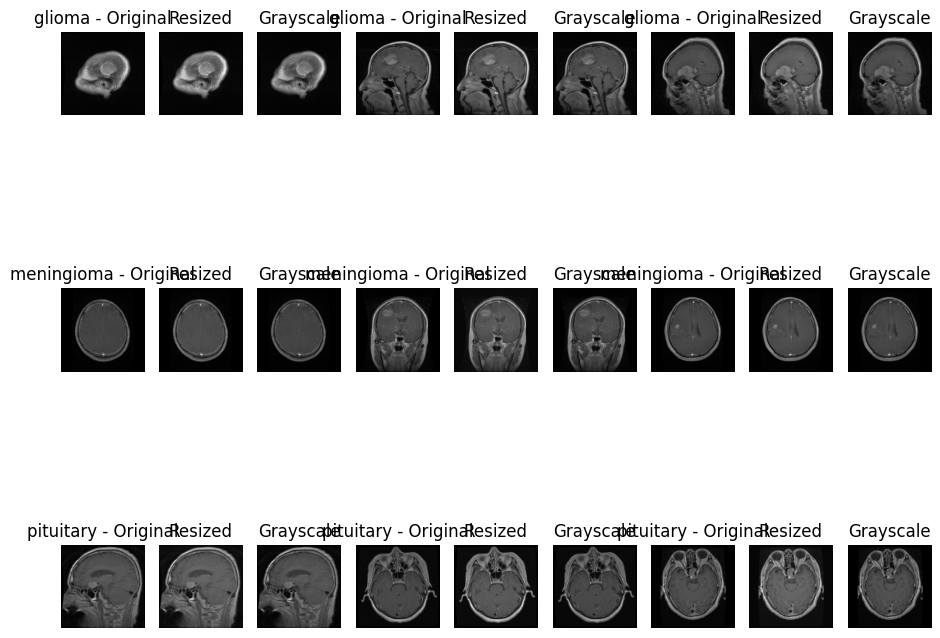

In [4]:
# Visualize some sample images
visualize_sample_images(data_folder, tumor_types, IMG_SIZE)

In [5]:
# 📌 LOAD IMAGES (grayscale + resize + equalizeHist)
def load_images_from_folder(folder):
    images, labels = [] , []
    for tumor_type_idx, tumor_type in enumerate(tumor_types, start=1):
        tumor_folder = os.path.join(folder, str(tumor_type_idx))
        for filename in os.listdir(tumor_folder):
            img_path = os.path.join(tumor_folder, filename)
            try:
                img = Image.open(img_path).convert('L')
                img = img.resize((IMG_SIZE, IMG_SIZE))
                img = np.array(img)
                img = cv2.equalizeHist(img)
                img = np.expand_dims(img, axis=-1)
                images.append(img)
                labels.append(tumor_type)
            except:
                continue
    return np.array(images), np.array(labels)

images, labels = load_images_from_folder(data_folder)
images = images.astype("float32") / 255.0


In [6]:
# ============================
# 📌 LABEL ENCODING
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_cat = to_categorical(labels_encoded)


In [7]:
# ============================
# 📌 TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    images, labels_cat, test_size=0.2, stratify=labels_cat, random_state=42
)

In [8]:
# ============================
# 📌 IMAGE AUGMENTATION
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
train_gen = datagen.flow(X_train_new, y_train_new, batch_size=32)
val_gen = datagen.flow(X_val, y_val, batch_size=32)

In [9]:
# ============================
# 📌 MODEL DEFINITIONS CNN
def build_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
# ============================
# 📌 MODEL DEFINITIONS ALEXNET
def build_alexnet(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(256, (5,5), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(384, (3,3), padding="same", activation='relu'),
        tf.keras.layers.Conv2D(256, (3,3), padding="same", activation='relu'),
        tf.keras.layers.MaxPooling2D((3,3), strides=(2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(4096, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [11]:
# ============================
# 📌 VGG16
def build_vgg16(input_shape, num_classes):
    base_model = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(3, (3,3), padding='same', input_shape=input_shape),
        base_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model




In [12]:

# ============================
# 📌 GAN MODEL DEFINITIONS
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(128 * 38 * 38, activation="relu", input_dim=100),
        tf.keras.layers.Reshape((38, 38, 128)),
        tf.keras.layers.UpSampling2D(),  # -> (76, 76)
        tf.keras.layers.Conv2D(128, kernel_size=3, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.ReLU(),
        tf.keras.layers.UpSampling2D(),  # -> (152, 152)
        tf.keras.layers.Conv2D(64, kernel_size=3, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh"),
        tf.keras.layers.Cropping2D(cropping=((1, 1), (1, 1)))  # Crop to (150, 150)
    ])
    return model
def build_discriminator(img_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, kernel_size=3, strides=2, input_shape=img_shape, padding="same"),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(64, kernel_size=3, strides=2, padding="same"),
        tf.keras.layers.ZeroPadding2D(padding=((0, 1), (0, 1))),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Conv2D(128, kernel_size=3, strides=2, padding="same"),
        tf.keras.layers.BatchNormalization(momentum=0.8),
        tf.keras.layers.LeakyReLU(alpha=0.2),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(len(tumor_types), activation='softmax')  # Number of classes = 3 here
    ])
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [13]:
# === GAN TRAINING FUNCTION ===
def train_gan(X_train, y_train, epochs=10, batch_size=64):
    generator = build_generator()
    discriminator = build_discriminator((IMG_SIZE, IMG_SIZE, 1))

    discriminator.trainable = False
    z = tf.keras.Input(shape=(100,))
    img = generator(z)
    validity = discriminator(img)
    combined = tf.keras.Model(z, validity)
    combined.compile(loss='categorical_crossentropy', optimizer='adam')

    half_batch = batch_size // 2
    for epoch in range(epochs):
        idx = np.random.randint(0, X_train.shape[0], half_batch)
        imgs = X_train[idx]
        labels = y_train[idx]

        noise = np.random.normal(0, 1, (half_batch, 100))
        gen_imgs = generator.predict(noise)

        d_loss_real = discriminator.train_on_batch(imgs, labels)
        fake_labels = tf.keras.utils.to_categorical(np.random.randint(0, len(tumor_types), half_batch), num_classes=len(tumor_types))
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake_labels)

        noise = np.random.normal(0, 1, (batch_size, 100))
        valid_y = tf.keras.utils.to_categorical(np.ones(batch_size), num_classes=len(tumor_types))
        g_loss = combined.train_on_batch(noise, valid_y)

        if epoch % 1 == 0:  # Log every epoch
            print(f"Epoch {epoch + 1}/{epochs} - D real loss: {d_loss_real[0]:.4f}, D fake loss: {d_loss_fake[0]:.4f}, G loss: {g_loss:.4f}")

    return discriminator

In [14]:
# ============================
# TRAIN BASE MODELS
input_shape = (IMG_SIZE, IMG_SIZE, 1)

print("Building and training CNN...")
cnn_model = build_cnn(input_shape, len(tumor_types))
cnn_model.fit(train_gen, validation_data=val_gen, epochs=10)

print("Building and training AlexNet...")
alexnet_model = build_alexnet(input_shape, len(tumor_types))
alexnet_model.fit(train_gen, validation_data=val_gen, epochs=10)

print("Building and training VGG16...")
vgg16_model = build_vgg16((IMG_SIZE, IMG_SIZE, 1), len(tumor_types))
vgg16_model.fit(train_gen, validation_data=val_gen, epochs=10)

# ============================
# === TRAIN GAN (Discriminator as classifier) ===
print("Training GAN discriminator as classifier...")
gan_discriminator = train_gan(X_train, y_train, epochs=10, batch_size=64)

# ============================
# PREDICTIONS FOR ENSEMBLE
pred_cnn = cnn_model.predict(X_test)
pred_alex = alexnet_model.predict(X_test)
pred_vgg = vgg16_model.predict(X_test)
pred_gan = gan_discriminator.predict(X_test)

y_true = np.argmax(y_test, axis=1)

print("\nIndividual model accuracies:")
print("CNN:", accuracy_score(y_true, np.argmax(pred_cnn, axis=1)))
print("AlexNet:", accuracy_score(y_true, np.argmax(pred_alex, axis=1)))
print("VGG16:", accuracy_score(y_true, np.argmax(pred_vgg, axis=1)))
print("GAN Discriminator:", accuracy_score(y_true, np.argmax(pred_gan, axis=1)))


Building and training CNN...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1761657995.662479      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761657995.663096      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1761657999.173770     109 service.cc:148] XLA service 0x78dd40009dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761657999.174905     109 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1761657999.174925     109 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1761657999.455138     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


 5/69 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3909 - loss: 2.8971

...

69/69 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.4308 - loss: 1.5787 - val_accuracy: 0.5366 - val_loss: 0.9652
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5791 - loss: 0.9222 - val_accuracy: 0.6057 - val_loss: 0.8875
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6506 - loss: 0.7979 - val_accuracy: 0.6179 - val_loss: 0.8206
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6369 - loss: 0.8025 - val_accuracy: 0.6098 - val_loss: 0.7452
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6837 - loss: 0.7013 - val_accuracy: 0.6463 - val_loss: 0.7489
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6622 - loss: 0.7396 - val_accuracy: 0.6545 - val_loss: 0.7155
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6555 - loss: 0.7335 - val_accuracy: 0.7114 - val_loss: 0.6199
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6954 - loss: 0.6512 - val_accuracy: 0.6382 - val_loss: 

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


/usr/local/lib/python3.11/dist-packages/keras/src/backend/tensorflow/trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/10 - D real loss: 1.0947, D fake loss: 1.0966, G loss: 1.0841
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Epoch 2/10 - D real loss: 1.0952, D fake loss: 1.0962, G loss: 0.9667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 3/10 - D real loss: 1.0968, D fake loss: 1.0972, G loss: 0.8677
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Epoch 4/10 - D real loss: 1.0959, D fake loss: 1.0962, G loss: 0.7835
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 5/10 - D real loss: 1.0978, D fake loss: 1.0982, G loss: 0.7224
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 6/10 - D real loss: 1.0985, D fake loss: 1.0991, G loss: 0.6721
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Epoch 7/10 - D real loss: 1.0997, D fake loss: 1.0982, G loss: 0.6286
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Epoch 8/10 - D real loss: 1.0981, D fake loss: 1.0994, G loss: 0.5876
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Epoch 9/10 - D real loss: 1.1004, D fake loss: 1.1020, G loss: 0.5540
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Epoch 10/10 - D real loss: 1

In [15]:
#Only Ensemble
avg_pred = (pred_cnn + pred_alex + pred_vgg+pred_gan) / 4
avg_acc = accuracy_score(y_true, np.argmax(avg_pred, axis=1))
print("\nAverage Ensemble Accuracy:", avg_acc)


Average Ensemble Accuracy: 0.8107667210440457


In [16]:
# ============================
# GRID SEARCH FOR BEST ENSEMBLE WEIGHTS
preds = np.array([pred_cnn, pred_alex, pred_vgg, pred_gan])
results = []

for w1 in range(0, 11):
    for w2 in range(0, 11):
        for w3 in range(0, 11):
            for w4 in range(0, 11):
                total = w1 + w2 + w3 + w4
                if total == 0:
                    continue
                weights = [w1 / total, w2 / total, w3 / total, w4 / total]
                weighted_preds = np.tensordot(preds, weights, axes=((0), (0)))
                y_pred = np.argmax(weighted_preds, axis=1)
                acc = accuracy_score(y_true, y_pred) * 100
                results.append({
                    'w_cnn': weights[0],
                    'w_alex': weights[1],
                    'w_vgg': weights[2],
                    'w_gan': weights[3],
                    'accuracy': acc
                })

df = pd.DataFrame(results)
best = df.loc[df['accuracy'].idxmax()]
print(f"\n✅ Best Weighted Accuracy: {best['accuracy']:.2f}%")
print(f"Optimal Weights -> CNN: {best['w_cnn']:.2f}, AlexNet: {best['w_alex']:.2f}, VGG16: {best['w_vgg']:.2f}, GAN: {best['w_gan']:.2f}")



✅ Best Weighted Accuracy: 85.81%
Optimal Weights -> CNN: 0.00, AlexNet: 0.00, VGG16: 0.56, GAN: 0.44


In [17]:
# === ii) Weighted Average Ensemble ===
# Example weights - You can modify based on model accuracy
w_cnn = 0.41
w_alex = 0.06
w_vgg = 0.4
w_gan = 0.1


weighted_pred = (w_cnn * pred_cnn) + (w_alex * pred_alex) + (w_vgg * pred_vgg)+(w_vgg * pred_gan)
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# Accuracy
weighted_accuracy = accuracy_score(y_true, weighted_pred_labels)
print(f"\n📌 Weighted Average Ensemble Accuracy: {weighted_accuracy:.4f}")


📌 Weighted Average Ensemble Accuracy: 0.8026



FINAL WEIGHTED ENSEMBLE PERFORMANCE

🎯 Final Weighted Ensemble Accuracy: 0.8581

📄 Classification Report:
              precision    recall  f1-score   support

      glioma       0.78      0.58      0.67       142
  meningioma       0.87      0.91      0.89       285
   pituitary       0.88      0.99      0.93       186

    accuracy                           0.86       613
   macro avg       0.84      0.83      0.83       613
weighted avg       0.85      0.86      0.85       613



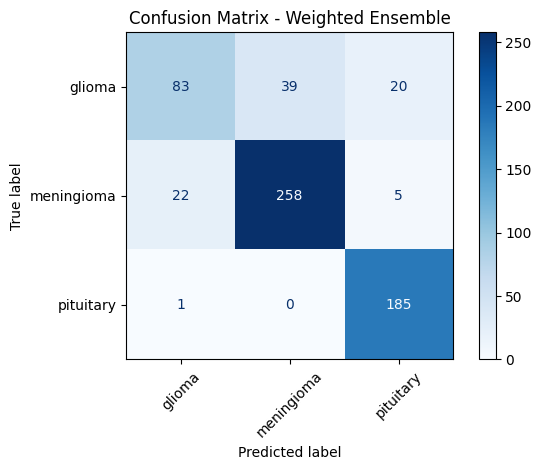

In [18]:
# ============================
# FINAL EVALUATION WITH BEST WEIGHTS
# ============================
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Apply optimal weights from best grid search result
w_cnn = best['w_cnn']
w_alex = best['w_alex']
w_vgg = best['w_vgg']
w_gan = best['w_gan']

# Combine weighted predictions
weighted_pred = (w_cnn * pred_cnn) + (w_alex * pred_alex) + (w_vgg * pred_vgg) + (w_gan * pred_gan)
weighted_pred_labels = np.argmax(weighted_pred, axis=1)

# ============================
# FINAL PERFORMANCE EVALUATION
# ============================

print("\n==============================")
print("FINAL WEIGHTED ENSEMBLE PERFORMANCE")
print("==============================")

# Final accuracy
final_acc = accuracy_score(y_true, weighted_pred_labels)
print(f"\n🎯 Final Weighted Ensemble Accuracy: {final_acc:.4f}")

# Classification report
print("\n📄 Classification Report:")
print(classification_report(y_true, weighted_pred_labels, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, weighted_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Weighted Ensemble")
plt.tight_layout()
plt.show()


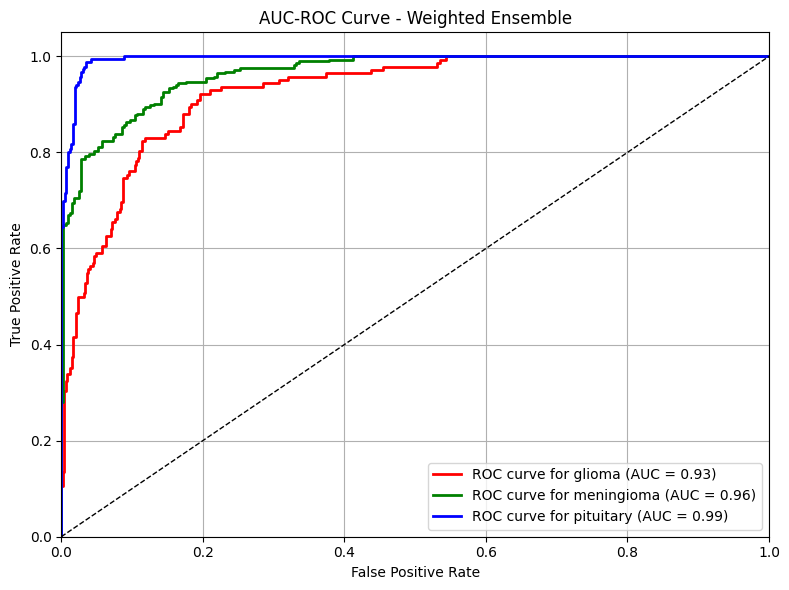

In [19]:
# ============================
# ROC Curve & AUC
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(len(tumor_types)))
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], weighted_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue', 'purple']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'ROC curve for {le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve - Weighted Ensemble")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

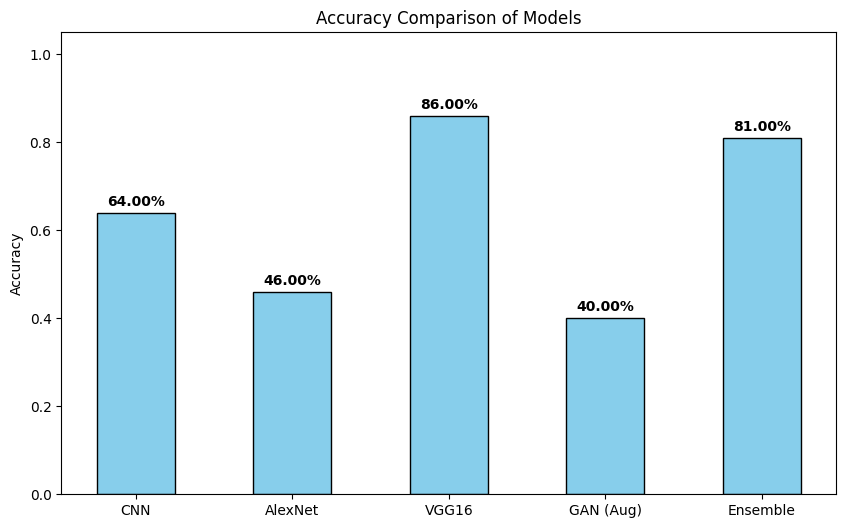

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Actual accuracies
models = ["CNN", "AlexNet", "VGG16", "GAN (Aug)", "Ensemble"]
accuracy = [0.64, 0.46, 0.86, 0.40, 0.81]

x = np.arange(len(models))
width = 0.5

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(x, accuracy, width, color="skyblue", edgecolor="black")

ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison of Models')
ax.set_xticks(x)
ax.set_xticklabels(models)

# Add accuracy values above each bar (percentage format)
for bar, acc in zip(bars, accuracy):
    height = bar.get_height()
    ax.annotate(f'{acc*100:.2f}%',   # convert to %
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.ylim(0, 1.05)  # scale up to 100% = 1.0
plt.show()


In [21]:
# ============================
# 📉 LOSS FUNCTION EVALUATION (for Optimal Weights)
# ============================
from sklearn.metrics import (
    log_loss, mean_absolute_error,
    mean_squared_error, cohen_kappa_score, hamming_loss
)

# Use the weighted predictions you already computed during grid search
# (Make sure 'weighted_preds' and 'y_pred' or 'weighted_pred_labels' are already available)

# === Compute Loss Metrics ===
logloss = log_loss(y_true, weighted_preds)
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred)
h_loss = hamming_loss(y_true, y_pred)

# === Display Results ===
print("\n==============================")
print("📉 LOSS FUNCTION METRICS (Optimal Weights)")
print("==============================")
print(f"🔻 Log Loss (Cross-Entropy): {logloss:.4f}")
print(f"🔸 Mean Absolute Error: {mae:.4f}")
print(f"🔹 Mean Squared Error: {mse:.4f}")
print(f"📘 Cohen's Kappa Score: {kappa:.4f}")
print(f"📕 Hamming Loss: {h_loss:.4f}")



📉 LOSS FUNCTION METRICS (Optimal Weights)
🔻 Log Loss (Cross-Entropy): 0.6913
🔸 Mean Absolute Error: 0.2349
🔹 Mean Squared Error: 0.3263
📘 Cohen's Kappa Score: 0.6928
📕 Hamming Loss: 0.1892
